## Alunos:
- Igor Correa Trifilio Campos - 202365092AB
- Davi Luís de Faria Rocha - 202365519B


In [28]:
!pip install anastruct

from PIL import Image
import matplotlib.pyplot as plt
from urllib.request import urlopen
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from anastruct import SystemElements

Defaulting to user installation because normal site-packages is not writeable


# Questão 1

# Estrutura escolhida: Portão da Índia
## [Link para a modelagem 3D no google arts and culture](https://artsandculture.google.com/asset/3d-model-of-gateway-of-india-india-cyark/JAE__LXR9I6lkA?hl=en) feita por [CyArk](https://www.cyark.org/whoweare/)


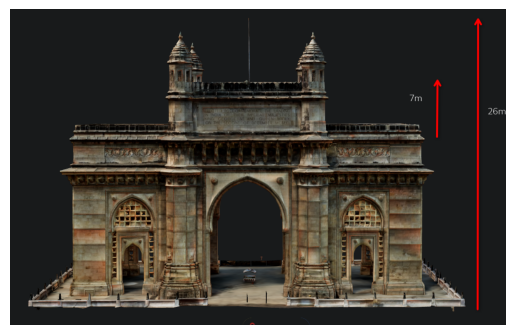

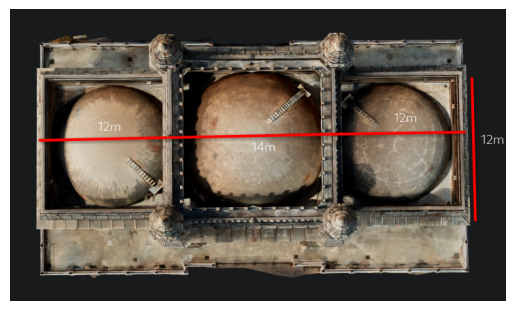

In [29]:
def carregador_imagem(nome_arquivo):
    url = 'https://raw.githubusercontent.com/Rogire/Trabalho-MAC019/main/images/' + nome_arquivo
    img = Image.open(urlopen(url))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
carregador_imagem("altura.png")
carregador_imagem("largura.png")

## Características
### Informações conhecidas
- 26 Metros de altura
- O domo principal da estrutura possui 14 metros de diâmetro
- A estrutura é feita de basalto e concreto armado
- A estrutura simétrica logo os lados opostos vão ter módulos iguais

### Aproximações
Por falta de informações públicas divulgadas sobre a estrutura, algumas aproximações foram feitas
- O valor dos demais domos foi aproximado como 11 metros
    - 3 domos: 11 + 14 + 11 =36 Metros de largura
    - 12 metros de espessura
- A laje que compõe o carregamento distribuído sobre a viga tem 4 paredes, 3 torres e uma cúpula oca
  -  O carregamento distribuído considerado foi o de uma das paredes e multiplicado por um fator de segurança, considerando a **densidade cúbica** da parede
  - A altura das paredes foi estimada como o raio de seu domo, sendo 6 metros para as paredes das pontas e 7 metros para a do meio
  - A largura das paredes da ponta foi estimada pelo valor do diâmetro dos domos: 12 metros
  - Por falta de informações, **a espessura das paredes foi estimada como 1 metro, e seção transversal como 3 metros**
- A densidade do basalto com centro armado foi aproximada como  $ρ ≈ 2500 kg/m³ (≈ 25 kN/m³)$ tendo em vista os valores usuais em construções.
#### Estimativa do módulo de Elasticidade e momento de Inércia
- Os valores regulares do E para concreto armado variam entre 25 e 30 GPa, então o valor de 27.5 GPa foi adotado para considerar uma margem uniforme
- Considerando a estrutura como vigas retangulares o momento de inércia para todas as barras do sistema segue a mesma fórmula tabelada $I = \frac{bh³}{12}$

#### Estimativa do carregamento distribuído

- O carregamento distribuído das lajes sobre cada barra foi aproximado pelo peso das paredes multiplicado por um fator de correção para considerar os demais elementos presentes
- Paredes das bordas:
  - $V_B = a*b*h = 11*6*1 = 66 m³$
- Parede central:
  - $V_C = a*b*h = 14*7*1 = 98m³$

- O fator de correção foi colocado como 30%: $\delta = 1.3$

- Massa valor central:
  - $M_c = V_C * \delta * \rho= 98 * 1.3 *2500 = 318500 Kg \approx 3.185*10^5 Kg$

- Massa valor bordas:
  - $M_b = V_B * \delta * \rho= 66 * 1.3 *2500 = 214500 Kg ≈ 2.145*10^5 Kg$

- Os carregamentos vão ser dado pelo peso dessas estruturas
  - Q = $M_c*g \approx 3.185*10^5 * 9.81 = 31,24485 *10^5 \approx 3,1 * 10^6$
  - q = $M_b*g \approx 2.145*10^5 * 9.81 = 20,9934 *10^5  \approx 2,1 * 10^6$

### Simplificação Adotada: Simplificação de barras inextensíveis
  - Considerando as barras da viga principal como inextensíveis, os nós do sistema passam a ter apenas um grau de liberdade e dessa forma tem **4 Deslocabilidades e 5 casos**

## Dois métodos de resolução:
### Analítico
- A resolução foi feita na mão até montar a matriz de deslocabilidade K para as deslocabilidades dos nós 1,2,3 e 4, depois disso pode resolver com Python, os diagramas podem ser feito em Python ou na mão

## Numérico
- Com a simplificação -> 4 Deslocabilidades
- Sem a simplificação




# Solução dos casos
#### Caso 0:
  No primeiro caso, supomos deslocamento em nenhum dos nós do sistema, dessa forma o valor de cada k se torna o valor do próprio momento de engastamento perfeito, que considera as infliências de todas as barras conectadas aquele nó. Dessa forma os valores são dados diretamente pela tabela:

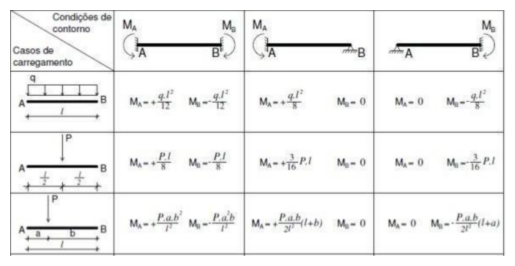

In [30]:
carregador_imagem('tabela_momento_perfeito.png')

Dessa forma a os valores encontrados para o caso 0 são:
$ \beta _{10}= 2.11 \cdot 10^7$
$ \beta _{20}= 2.95 \cdot 10^7$
$ \beta _{30}= -2.95 \cdot 10^7$
$ \beta _{40}= -2.11 \cdot 10^7$


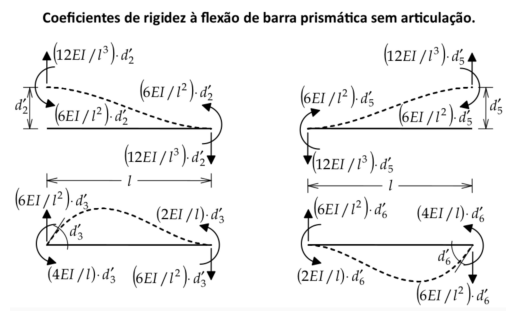

In [31]:
carregador_imagem('tabela_flexao_rigidez.png')

# Montagem da matriz analítica K


A montagem da matriz leva em conta o deslocamento da matriz estrutura em cada caso, e a força de resistência $k_{ij}$ que surge em cada barra sempre considerando as contribuições de cada uma das barras da viga e pilar conectada aos nós.

In [32]:
#imagem resolução

Dessa forma, o sistema final fica estabelecido como:

$$
\begin{equation}
\begin{bmatrix}
\beta_{10} \\
\beta_{20} \\
\beta_{30} \\
\beta_{40}
\end{bmatrix}
+
\begin{bmatrix}
k_{11} & k_{12} & 0 & 0 \\
k_{21} & k_{22} & k_{23} & 0 \\
0 & k_{32} & k_{33} & k_{34} \\
0 & 0 & k_{43} & k_{44}
\end{bmatrix}
\cdot
\begin{bmatrix}
D_1 \\
D_2 \\ 
D_3 \\ 
D_4 
\end{bmatrix}
=
\begin{bmatrix}
0 \\ 0 \\ 0 \\ 0
\end{bmatrix}
\end{equation}
$$

Que é equivalente a:

$$
\begin{equation}

\begin{bmatrix}
k_{11} & k_{12} & 0 & 0 \\
k_{21} & k_{22} & k_{23} & 0 \\
0 & k_{32} & k_{33} & k_{34} \\
0 & 0 & k_{43} & k_{44}
\end{bmatrix}
\cdot
\begin{bmatrix}
D_1 \\
D_2 \\ 
D_3 \\ 
D_4 
\end{bmatrix}
= -
\begin{bmatrix}
\beta_{10} \\
\beta_{20} \\
\beta_{30} \\
\beta_{40}
\end{bmatrix}

\end{equation}
$$


In [33]:
E = 2.75 * 10**10
l = 11
L = 14
h =19

I = (1*3**3)/12

EI = E*I

k11 = 4*EI*(1/h + 1/l)
k21 = (2*EI)/l
k31 = 0
k41 = 0

k12 = (2*EI)/l
k22 = 4*EI* (1/l + 1/L + 1/h)
k32 = 2*EI/L
k42 = 0

k13 = 0
k23 = 2*EI/L
k33 = 4*EI* (1/l + 1/L + 1/h)
k43 = 2*EI/l

k14 = 0
k24 = 0
k34 = 2*EI/l
k44 = 4*EI*(1/h + 1/l)

#Matrizes
B = np.array([2.11e7, 2.95e7, -2.95e7, -2.11e7])
K = np.array(
    [[k11,k12,k13,k14],
     [k21,k22,k23,k24],
     [k31,k32,k33,k34],
     [k41,k42,k43,k44]
    ])

#Orientando B como positivo
D = np.linalg.solve(K,-B)
print("K:",K)
print(f"Vetor D encontrado: [{D[0]},{D[1]},{D[2]},{D[3]}]")

K: [[3.55263158e+10 1.12500000e+10 0.00000000e+00 0.00000000e+00]
 [1.12500000e+10 5.32048872e+10 8.83928571e+09 0.00000000e+00]
 [0.00000000e+00 8.83928571e+09 5.32048872e+10 1.12500000e+10]
 [0.00000000e+00 0.00000000e+00 1.12500000e+10 3.55263158e+10]]
Vetor D encontrado: [-0.00041683631044927384,-0.0005592303646631119,0.0005592303646631119,0.00041683631044927384]


# Modelagem no Anastruct

Para simular a condição de barras inextensíveis que formam a estrutura que possui apenas 4 deslocabilidades, foi necessário colocar 

Estrutura


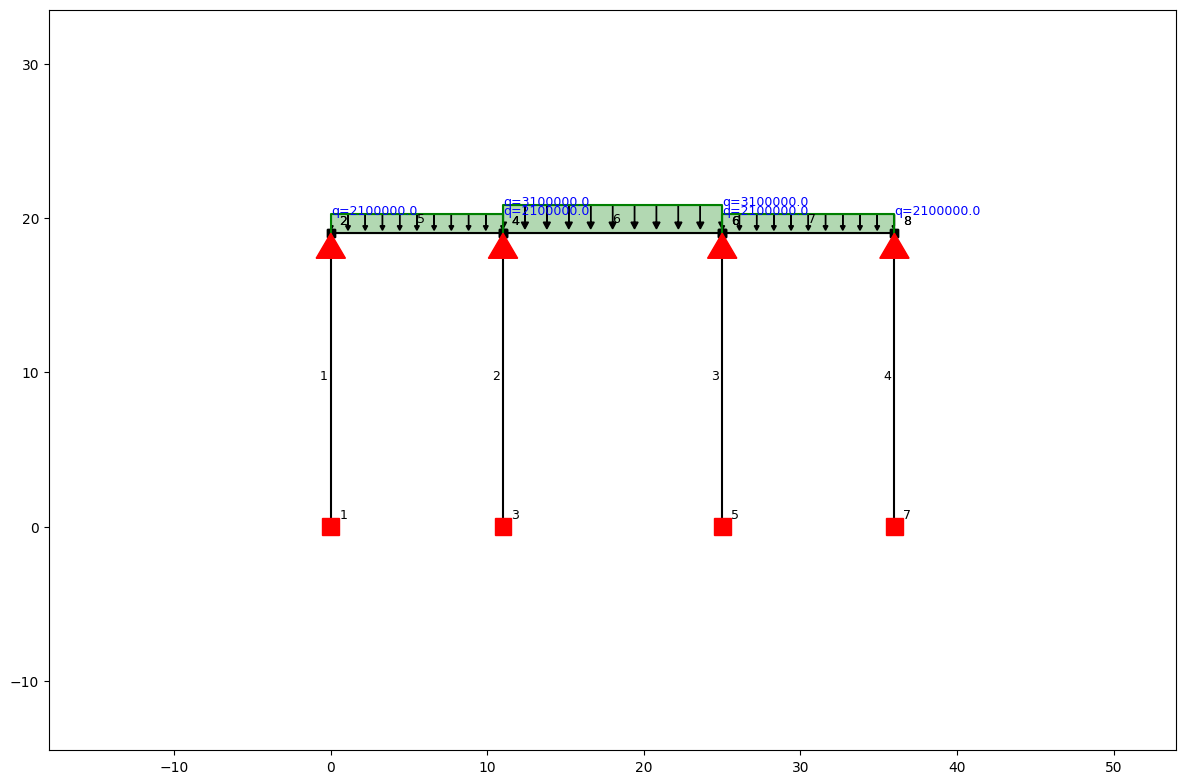

Reações de apoio


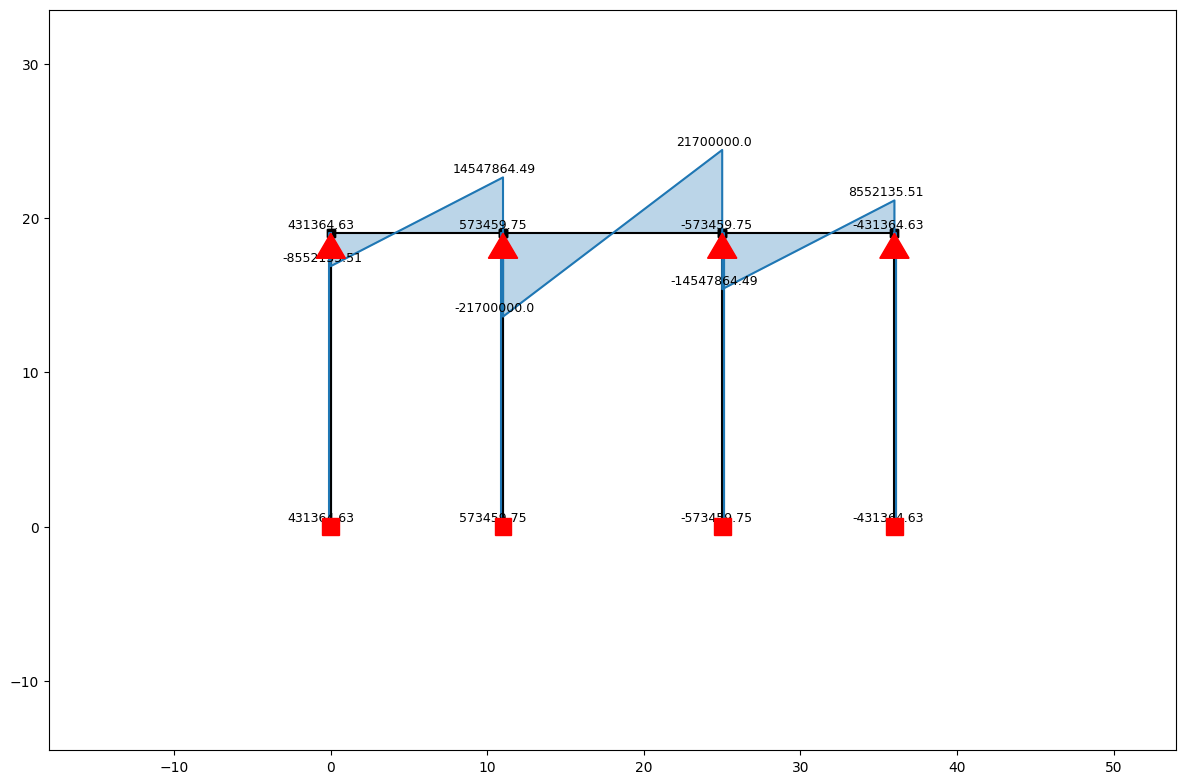

Diagrama de Momento Fletor


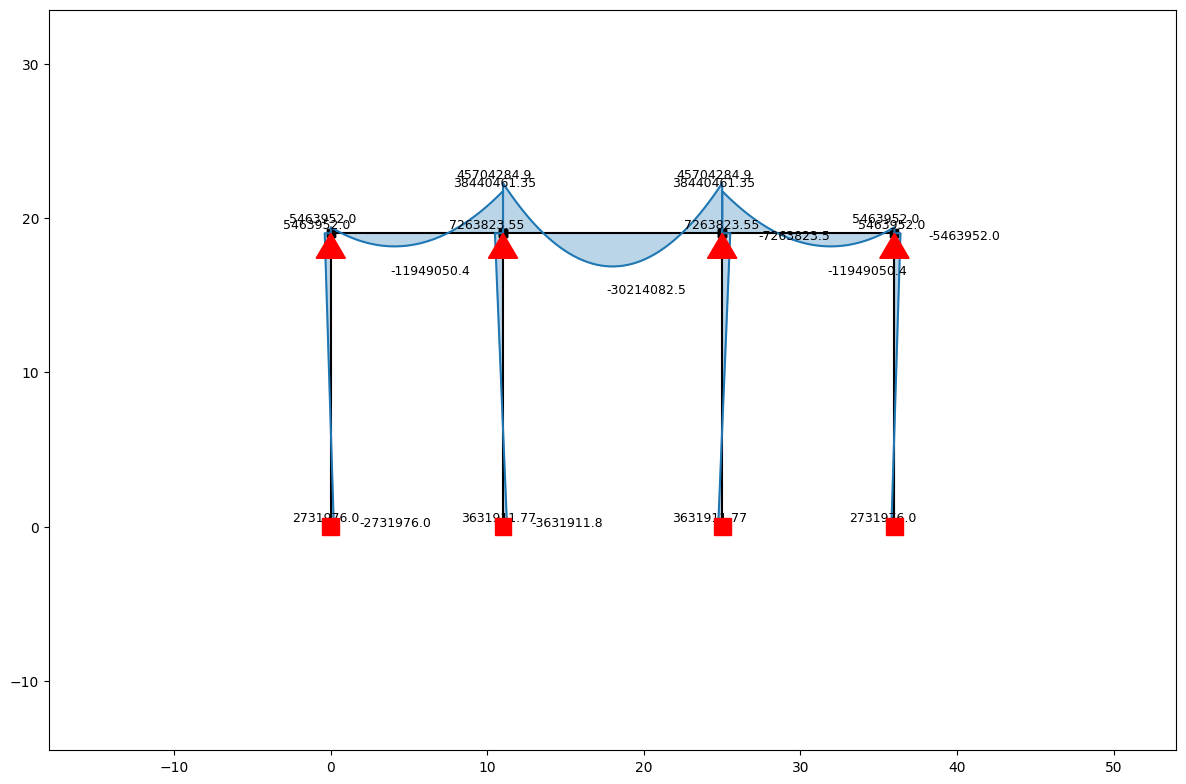

Linha elástica: 


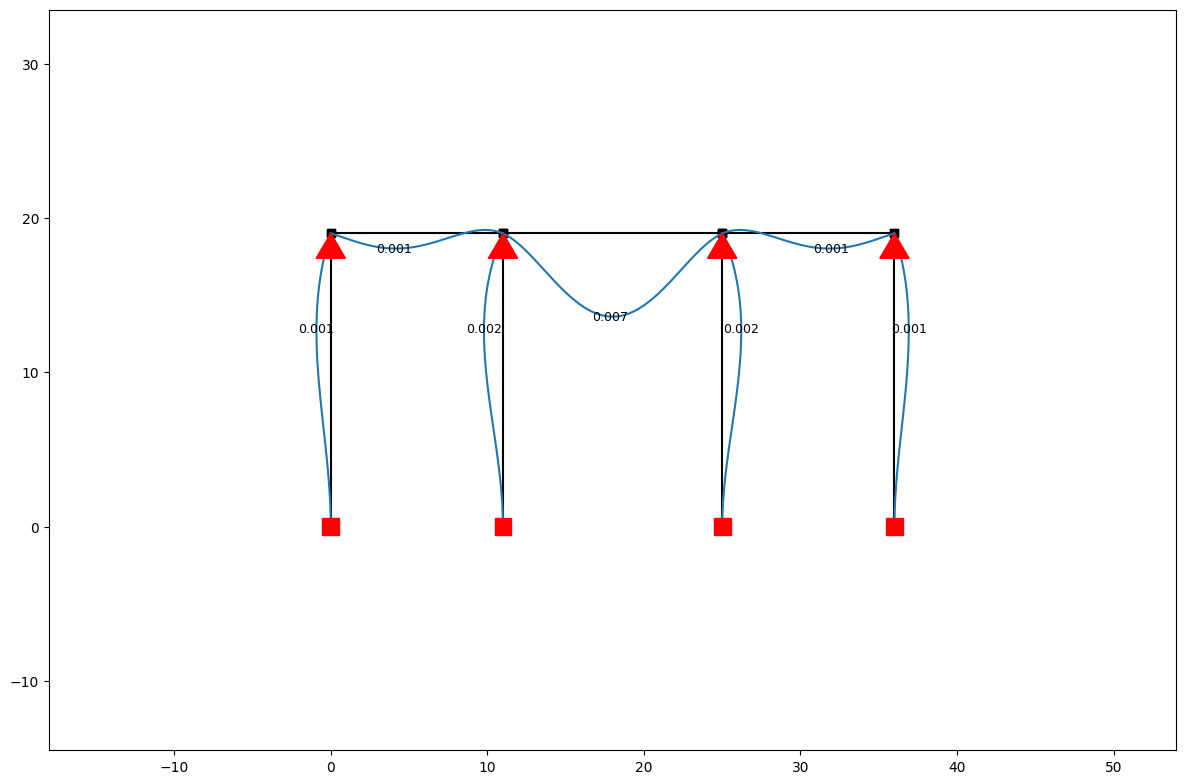

Deslocamentos por nó

{'id': 1, 'ux': np.float64(0.0), 'uy': np.float64(-0.0), 'phi_z': np.float64(-0.0)}
{'id': 2, 'ux': np.float64(0.0), 'uy': np.float64(-0.0), 'phi_z': np.float64(0.00041945490063634256)}
{'id': 3, 'ux': np.float64(0.0), 'uy': np.float64(-0.0), 'phi_z': np.float64(-0.0)}
{'id': 4, 'ux': np.float64(0.0), 'uy': np.float64(-0.0), 'phi_z': np.float64(0.0005576268580494472)}
{'id': 5, 'ux': np.float64(0.0), 'uy': np.float64(-0.0), 'phi_z': np.float64(-0.0)}
{'id': 6, 'ux': np.float64(0.0), 'uy': np.float64(-0.0), 'phi_z': np.float64(-0.0005576268580494448)}
{'id': 7, 'ux': np.float64(0.0), 'uy': np.float64(-0.0), 'phi_z': np.float64(-0.0)}
{'id': 8, 'ux': np.float64(0.0), 'uy': np.float64(-0.0), 'phi_z': np.float64(-0.00041945490063634197)}


In [34]:
SS = SystemElements(EI=EI, EA=1e15)

def solve_system(ss):
    print("Estrutura")
    ss.show_structure()
    ss.solve()
    print("Reações de apoio")
    ss.show_shear_force()
    print("Diagrama de Momento Fletor")
    ss.show_bending_moment()
    print("Linha elástica: ")
    ss.show_displacement()
    print("Deslocamentos por nó\n")
    for i in ss.get_node_displacements():
       print(i)    

elements = [
    [[0.0,0.0],[0.0,h]],
    [[l,0.0],[l,h]],
    [[l+L,0.0],[l+L,h]],
    [[2*l+L,0.0],[2*l+L,h]],

    [[0.0,h],[l,h]],
    [[l,h],[l+L,h]],
    [[l+L,h],[2*l+L,h]],
]
# Valores estimados de carregamento demonstrados acima
Q = 3.1e6
q = 2.1e6

for i in elements:
    SS.add_element(i)

SS.q_load(element_id=5,q=-q, direction='element')
SS.q_load(element_id=6,q=-Q, direction='element')
SS.q_load(element_id=7,q=-q, direction='element')


SS.add_support_hinged(node_id=2)
SS.add_support_hinged(node_id=4)
SS.add_support_hinged(node_id=6)
SS.add_support_hinged(node_id=8)


SS.add_support_fixed(node_id=1)
SS.add_support_fixed(node_id=3)
SS.add_support_fixed(node_id=5)
SS.add_support_fixed(node_id=7)


solve_system(SS)

## Comparação dos resultados
- Deslocamentos Matriz
  - $D1: -0.00041683631044927384 \approx 4.168*10^{-4}$
  - $D2: -0.0005592303646631119 \approx 5.559*10^{-4}$
  - $D3:  0.0005592303646631119 \approx 5.559*10^{-4}$
  - $D4:  0.00041683631044927384 \approx 4.168*10^{-4}$
- Deslocamentos Anastruct
  - $D1: 0.00041945490063634256 \approx 4.194*10^{-4}$
  - $D2: 0.0005576268580494472 \approx 5.576*10^{-4}$
  - $D3:-0.0005576268580494448 \approx 5.576*10^{-4}$
  - $D4:-0.0004194549006363419 \approx 4.194*10^{-4}$

Nota-se que a diferença entre os valores foi pequena, devido a aproximação do EA e aos erros de cálculo de ponto flutuante, arredondamento e etc. Além disso, os sinais entre cada um dos resultados está invertido, oque aconteceu devido a diferença na convenção de sinal usada pelo anastruct que considera momento horário como negativo e o anti-horário como positivo.

# Questão 2

# Aplicação prática escolhida: Amortecedor de um Uno Mille passando sobre quebra-mola
## Cenário:
Um Uno Mille 2001 com escada percorre um trecho liso e sem buracos de uma estrada a 60km/h quando se depara com um quebra-mola não sinalizado e o impacto da colisão é amortecido pelos amortecedores do carro.


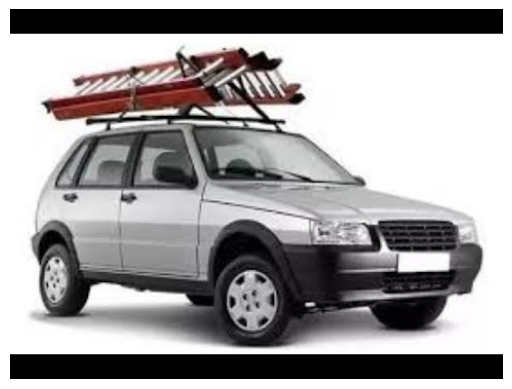

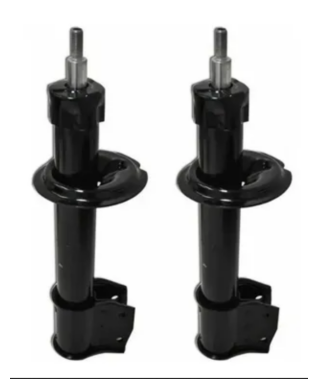

In [35]:
carregador_imagem("uno.png")
carregador_imagem("amortecedor.png")

# Escolha dos parâmetros:

## Massa `m`
  - A massa do uno é de cerca de 830 kg e distribuída aproximadamente em 60% na parte dianteira e 40% na traseira, e cerca de 4% da massa não é suspensa pelas rodas tendo isso em mente a massa que é sustentada pelos amortecedores pode ser aproximada por:
    -  dianteira = $m=\frac{0,6*830}{2}-30 \approx 220$ 
    - traseira $m=\frac{0,4*830}{2}-30 \approx 145$
  
  O valor escolhido levou em conta a massa sustentada pela parte dianteira do carro, somado pela massa média de uma escada longa no mercado (24kg) dividido por 4 para considerar cada roda.
 **Estimado: 250kg + 6 kg = 256 kg**

  
## Constante de amortecimento `c`
  - Amortecedores na indústria usam uma constante artificial ζ para fazer o controle do nível de amortecimento do sistema, o valor médio para carros de passeio populares é entre 0,2 e 0,4 então ele foi considerado como 0,3 para considerar uma margem ideal para o modelo, a expressão do amortecimento c é dada por:
  $$c=2ζ \sqrt{mk} = 2*0,3* \sqrt{250 * 20000} \approx 1340 Ns/m$$
  
## Constante elástica `k`
  - O uno Mille usa suspensões de MacPherson que utiliza uma mola helicoidal para absorver os impactos sofridos pelo veículo e sustentar o seu peso, um amortecedor que dissipa a energia vinda da mola e ajuda no controle das oscilações da carroceria e um braço de controle que conecta a roda ao chassi do veículo.
    - **Nesse modelo aproximaremos o amortecedor por sua mola helicoidal.**
  - Considerando que a frequência natural de suspensão ideal fica entre 1 e 1.5 Hz adotamos a frequência como $f_n=1,3 Hz$
  - Dessa forma a constante da mola k pode ser obtida a partir da frequência angular $w_n = 2\pi f_n = \sqrt \frac{k}{m} => k = m(2\pi f_n)² = 250 * (2\pi *1,2)² \approx 14200N/m $ 
  - A mola helicoidal do amortecedor trabalha com taxa progressiva linear, as médias de constantes de molas de Uno no mercado variam entre 15000 a 25000 N/m então aproximamos o valor para 15000/m para ter uma margem dos valores


In [ ]:
carregador_imagem("macPherson.jpg")

## $f(t)$
  - O tamanho do quebra-mola seguiu a definição da CONTRAN nº 600/2016 para lombadas físicas que diz que o tamanho de um quebra-mola deve ter entre 0,08m e 0,1m de altura(h) e comprimento(L) em 1,5m e 3m, os valores considerados foram de L=3m e h=0,1m
  - O período de contato do carro com o quebra mola é dado por $T=\frac{L}{v} = \frac{3m}{16,67m/s} \approx 0,18s$, com isso a excitação y(t) pode ser aproximada por



In [ ]:
carregador_imagem("lombada_tipo_A.png")

## $x_0$
  - O valor de deslocamento inicial é 0, pois não há força atuando sobre o amortecedor antes da colisão

## $v_0$
  - O valor da variação inicial é 0, pois não há força atuando sobre o amortecedor antes da colisão


# Solução
Dessa forma a equação se torna: 
$$
  256x'' + 1300x' + 15000x = 3024
$$

## Solução Numérica

## Comparação dos resultados

Comparando os resultados obtidos com a solução analítica presente no livro:

Solução Analítica


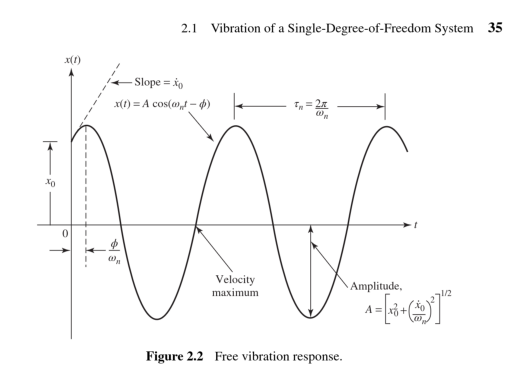

Solução numérica


In [36]:
print("Solução Analítica")
carregador_imagem("solucao_livro.png")
print("Solução numérica")
# ... 

notamos que